# Notebook 4 — Exploratory Data Analysis
**Karachi AQI — 3-Year Hourly Historical Data**

In [1]:
# Install dependencies (run once)
# !pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

CSV_PATH   = "aqi_backfill_engineered.csv"
PLOT_DIR   = Path("eda_plots")
PLOT_DIR.mkdir(exist_ok=True)

CAT_LABELS = {0:"Good (0-50)", 1:"Moderate (51-100)", 2:"Unhealthy/Sensitive (101-150)",
              3:"Unhealthy (151-200)", 4:"Very Unhealthy (201-300)", 5:"Hazardous (301+)"}
CAT_PALETTE = ["#00e400","#ffff00","#ff7e00","#ff0000","#8f3f97","#7e0023"]

print("✅ Imports done")

✅ Imports done


## 1. Load Data

In [3]:
df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Rows        : {len(df):,}")
print(f"Columns     : {len(df.columns)}")
print(f"Date range  : {df['timestamp'].min().date()}  →  {df['timestamp'].max().date()}")
print(f"AQI mean    : {df['aqi'].mean():.1f}  ±  {df['aqi'].std():.1f}")
print(f"AQI range   : {df['aqi'].min():.0f}  –  {df['aqi'].max():.0f}")
df.head()

Rows        : 26,136
Columns     : 66
Date range  : 2023-06-11  →  2026-06-04
AQI mean    : 86.3  ±  25.2
AQI range   : 32  –  259


,timestamp,city,aqi,pm25,pm10,o3,no2,so2,co,aqi_category,...,aqi_rolling_max_24h,aqi_rolling_min_24h,wind_x_pm25,humidity_x_pm25,temp_x_aqi,pollution_index,aqi_residual_168h,aqi_residual_72h,aqi_regime_range,next_hour_aqi
0,2023-06-11 19:00:00+00:00,karachi,70.984039,31.299999,48.299999,1.0,58.299999,49.299999,1169.0,1.0,...,71.598640,56.365246,64.450639,2327.378651,2108.226022,41.799999,6.536966,7.233812,15.233395,72.650711
1,2023-06-11 20:00:00+00:00,karachi,72.650711,27.600000,42.700001,4.0,52.500000,48.900002,1032.0,1.0,...,72.650711,56.365246,70.366470,2093.665294,2125.033298,37.110000,8.079727,8.615063,16.285465,73.971626
2,2023-06-11 21:00:00+00:00,karachi,73.971626,24.299999,37.700001,10.0,44.200001,46.400002,844.0,1.0,...,73.971626,56.365246,77.531850,1903.146270,2126.684256,32.300000,9.704289,10.065152,17.606380,74.973396
3,2023-06-11 22:00:00+00:00,karachi,74.973396,22.799999,35.299999,14.0,37.099998,42.200001,719.0,1.0,...,74.973396,56.365246,76.473516,1844.382552,2132.993182,29.409999,10.978134,11.154463,18.608150,75.815598
4,2023-06-11 23:00:00+00:00,karachi,75.815598,21.500000,33.400002,19.0,29.299999,36.400002,592.0,1.0,...,75.815598,56.365246,71.242576,1662.551899,2149.372219,26.630000,11.928717,11.912439,19.450352,76.542549


In [4]:
# Basic stats for key columns
df[["aqi","pm25","pm10","o3","no2","temperature","humidity","wind_speed"]].describe().round(2)

,aqi,pm25,pm10,o3,no2,temperature,humidity,wind_speed
count,26136.00,26136.00,26136.00,26136.00,26136.00,26136.00,26136.00,26136.00
mean,86.31,28.34,62.66,72.31,19.42,26.78,62.61,3.36
std,25.17,13.53,37.36,39.36,18.22,5.38,22.96,1.93
min,31.61,3.50,3.70,0.00,0.00,8.25,4.11,0.00
25%,68.24,19.20,39.20,44.00,7.30,23.75,46.01,1.96
50%,80.36,25.00,54.10,63.00,12.80,27.40,65.92,2.90
75%,98.82,33.60,75.40,96.00,25.10,30.30,82.14,4.38
max,259.32,159.70,504.80,375.00,154.10,46.35,100.00,13.71


## 2. AQI Distribution & Category Breakdown

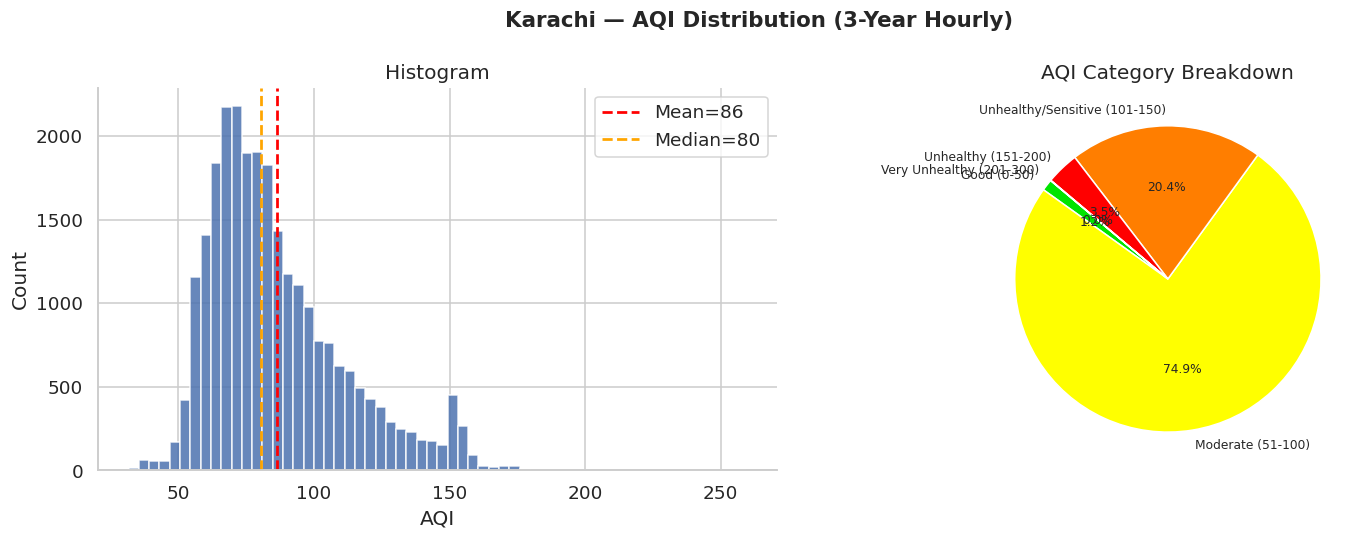

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Karachi — AQI Distribution (3-Year Hourly)", fontsize=14, fontweight="bold")

axes[0].hist(df["aqi"].dropna(), bins=60, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(df["aqi"].mean(),   color="red",    ls="--", lw=1.8, label=f"Mean={df['aqi'].mean():.0f}")
axes[0].axvline(df["aqi"].median(), color="orange", ls="--", lw=1.8, label=f"Median={df['aqi'].median():.0f}")
axes[0].set_xlabel("AQI"); axes[0].set_ylabel("Count"); axes[0].legend()
axes[0].set_title("Histogram")

cat_counts = df["aqi_category"].value_counts().sort_index()
labels  = [CAT_LABELS.get(int(k), str(k)) for k in cat_counts.index]
colors  = [CAT_PALETTE[int(k)] for k in cat_counts.index]
axes[1].pie(cat_counts, labels=labels, colors=colors, autopct="%1.1f%%",
            startangle=140, textprops={"fontsize": 8})
axes[1].set_title("AQI Category Breakdown")

plt.tight_layout()
plt.savefig(PLOT_DIR / "01_aqi_distribution.png", bbox_inches="tight")
plt.show()

## 3. Time-Series Overview

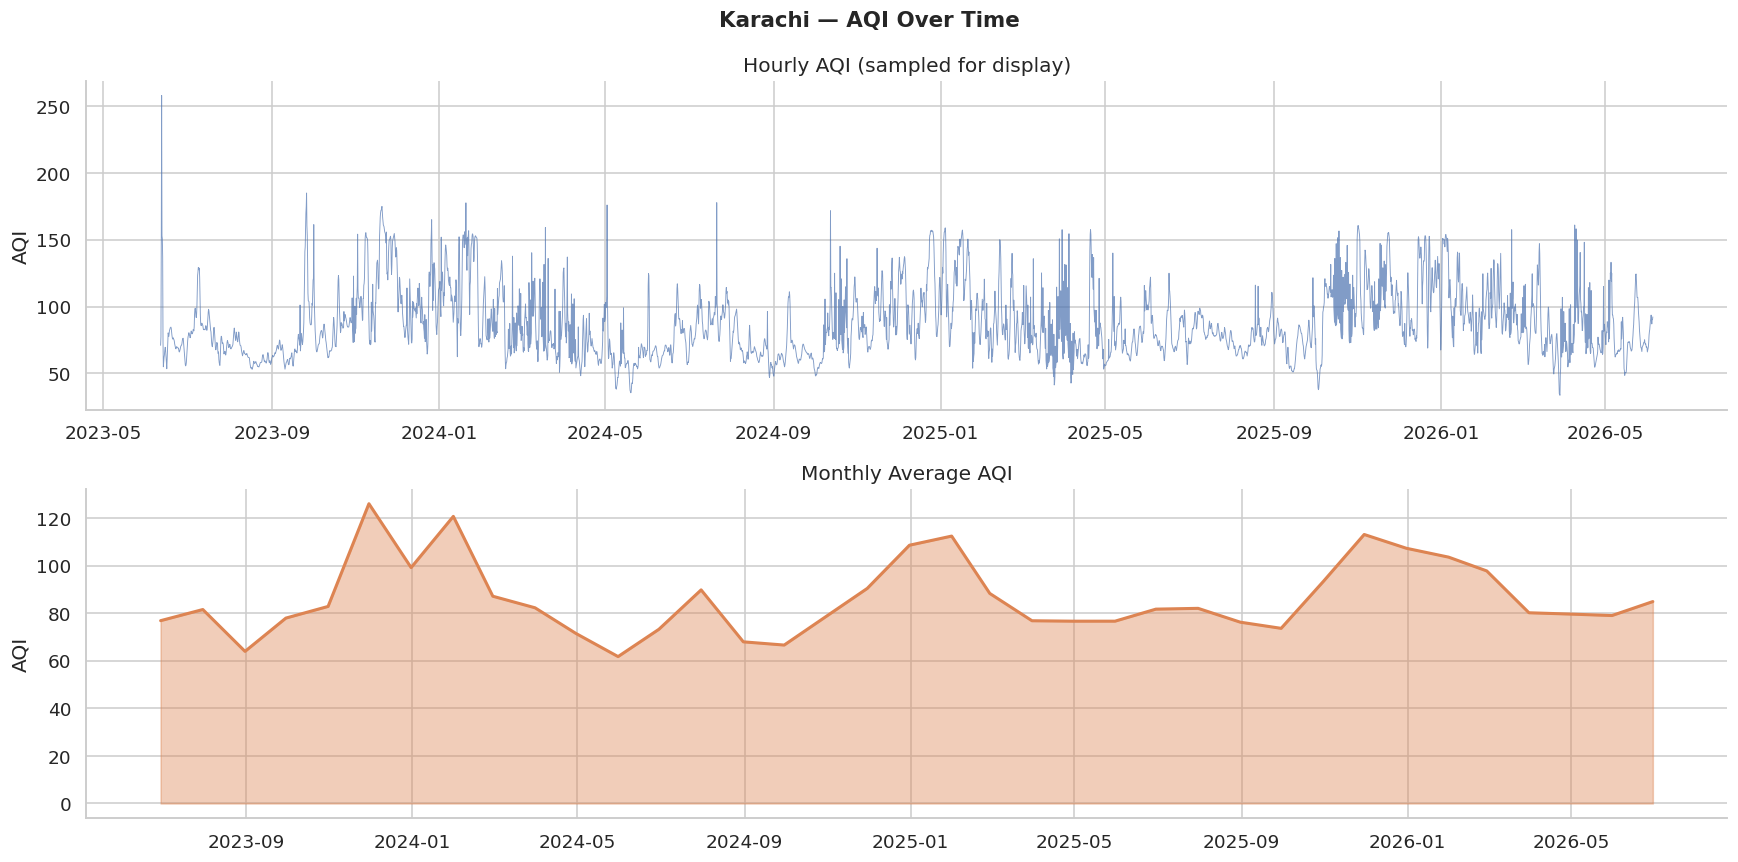

In [6]:
monthly = df.set_index("timestamp")["aqi"].resample("ME").mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle("Karachi — AQI Over Time", fontsize=14, fontweight="bold")

step = max(1, len(df) // 4000)
axes[0].plot(df["timestamp"][::step], df["aqi"][::step], color="#4C72B0", lw=0.6, alpha=0.7)
axes[0].set_ylabel("AQI"); axes[0].set_title("Hourly AQI (sampled for display)")

axes[1].fill_between(monthly.index, monthly, alpha=0.4, color="#DD8452")
axes[1].plot(monthly.index, monthly, color="#DD8452", lw=2)
axes[1].set_ylabel("AQI"); axes[1].set_title("Monthly Average AQI")

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_timeseries_overview.png", bbox_inches="tight")
plt.show()

## 4. Temporal Patterns — Hour, Day of Week, Month

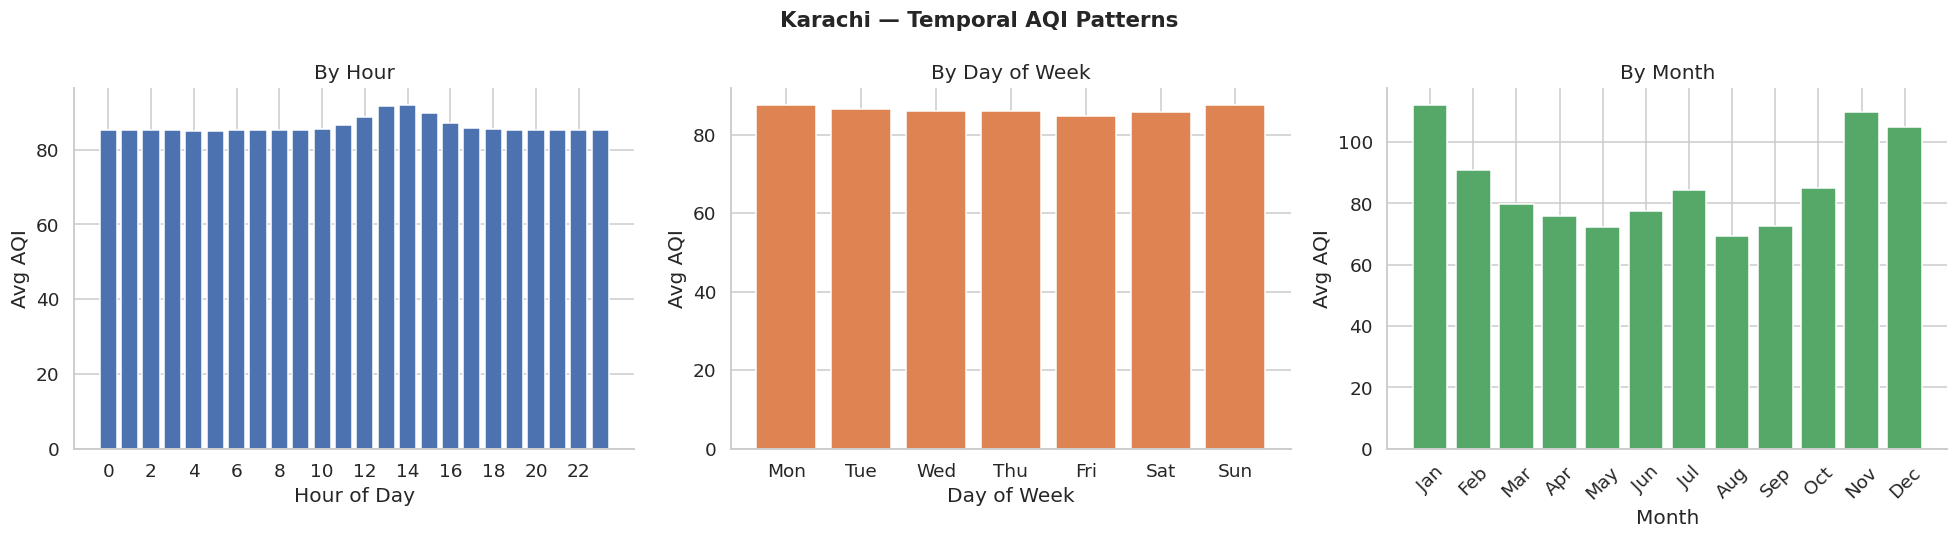

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Karachi — Temporal AQI Patterns", fontsize=14, fontweight="bold")

hourly_avg = df.groupby("hour")["aqi"].mean()
axes[0].bar(hourly_avg.index, hourly_avg.values, color="#4C72B0")
axes[0].set_xlabel("Hour of Day"); axes[0].set_ylabel("Avg AQI"); axes[0].set_title("By Hour")
axes[0].set_xticks(range(0, 24, 2))

dow_avg = df.groupby("day_of_week")["aqi"].mean()
axes[1].bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"][:len(dow_avg)], dow_avg.values, color="#DD8452")
axes[1].set_xlabel("Day of Week"); axes[1].set_ylabel("Avg AQI"); axes[1].set_title("By Day of Week")

month_avg = df.groupby("month")["aqi"].mean()
m_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[2].bar([m_names[int(m)-1] for m in month_avg.index], month_avg.values, color="#55A868")
axes[2].set_xlabel("Month"); axes[2].set_ylabel("Avg AQI"); axes[2].set_title("By Month")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(PLOT_DIR / "03_temporal_patterns.png", bbox_inches="tight")
plt.show()

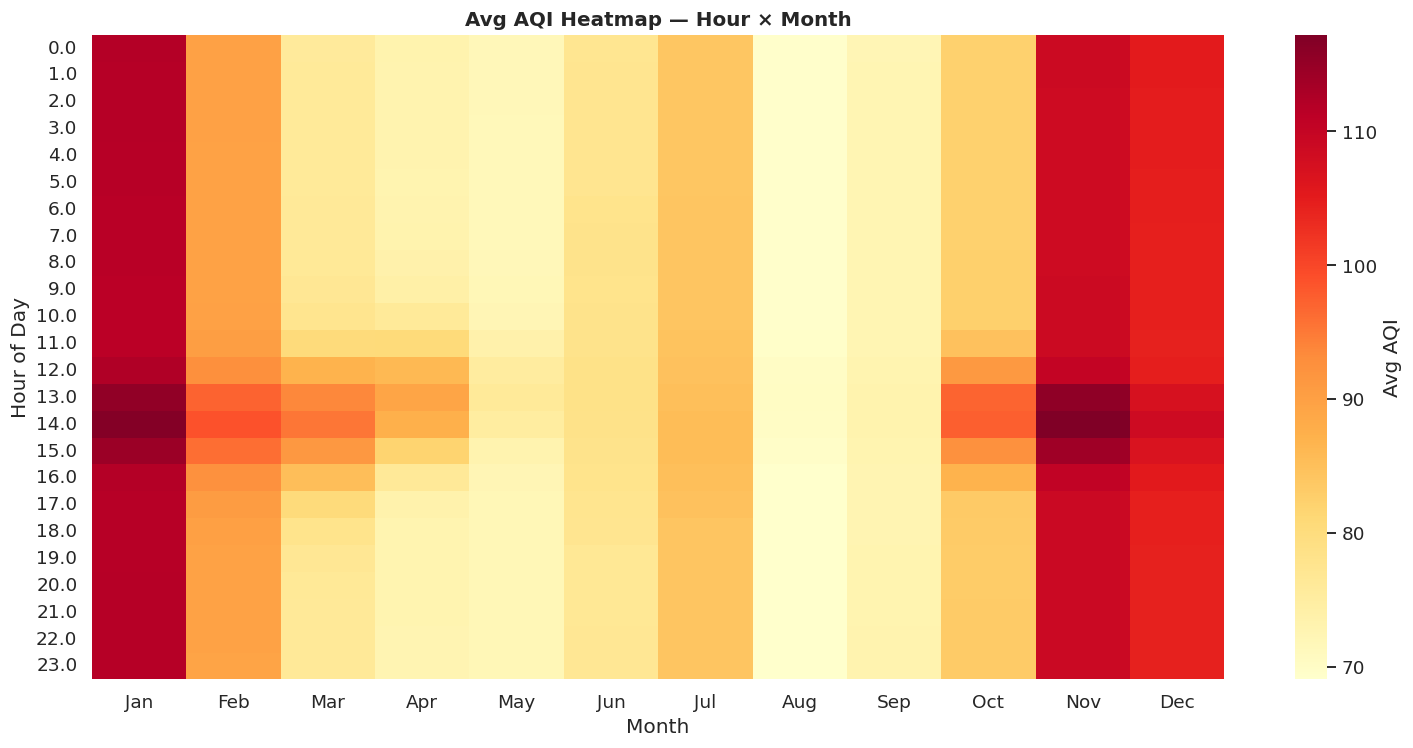

In [8]:
# Hour x Month heatmap
pivot = df.pivot_table(values="aqi", index="hour", columns="month", aggfunc="mean")

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, cmap="YlOrRd", ax=ax,
            xticklabels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
            cbar_kws={"label": "Avg AQI"})
ax.set_title("Avg AQI Heatmap — Hour × Month", fontsize=13, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("Hour of Day")
plt.tight_layout()
plt.savefig(PLOT_DIR / "04_heatmap_hour_month.png", bbox_inches="tight")
plt.show()

## 5. Seasonal Box Plots

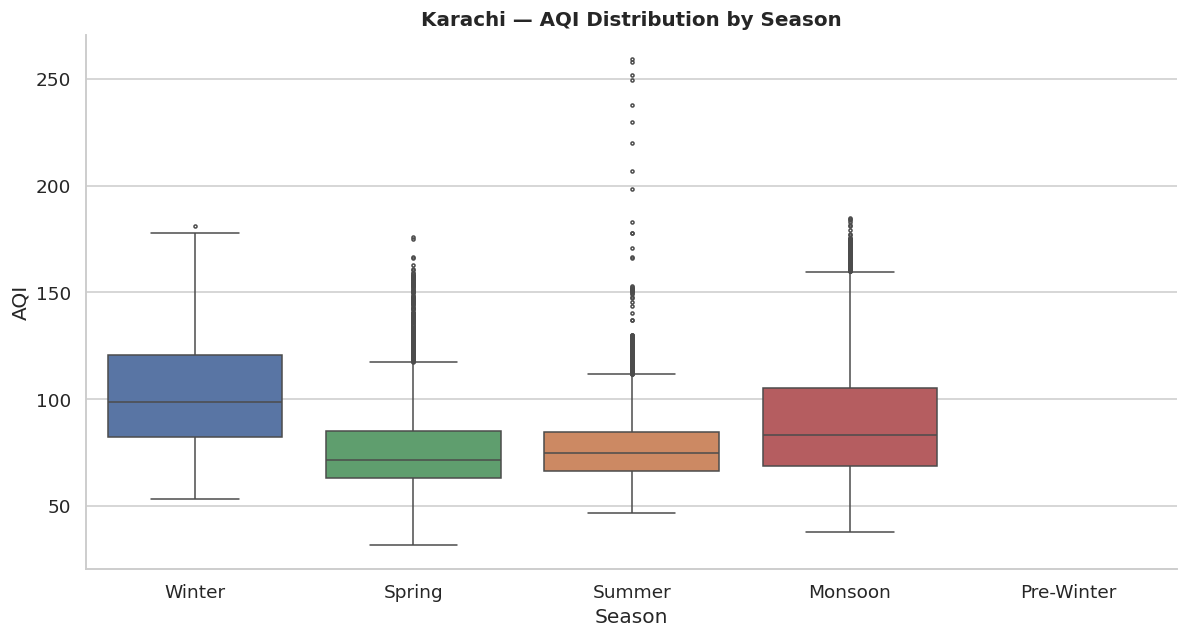

In [9]:
df2 = df.copy()
df2["season"] = pd.cut(df2["month"], bins=[0,2,5,8,11,12],
                        labels=["Winter","Spring","Summer","Monsoon","Pre-Winter"], right=True)
df2.loc[df2["month"] == 12, "season"] = "Winter"

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=df2, x="season", y="aqi",
            order=["Winter","Spring","Summer","Monsoon","Pre-Winter"],
            palette=["#4C72B0","#55A868","#DD8452","#C44E52","#8172B3"], ax=ax, fliersize=2)
ax.set_title("Karachi — AQI Distribution by Season", fontsize=13, fontweight="bold")
ax.set_xlabel("Season"); ax.set_ylabel("AQI")
plt.tight_layout()
plt.savefig(PLOT_DIR / "05_seasonal_boxplot.png", bbox_inches="tight")
plt.show()

## 6. Weather–AQI Relationships

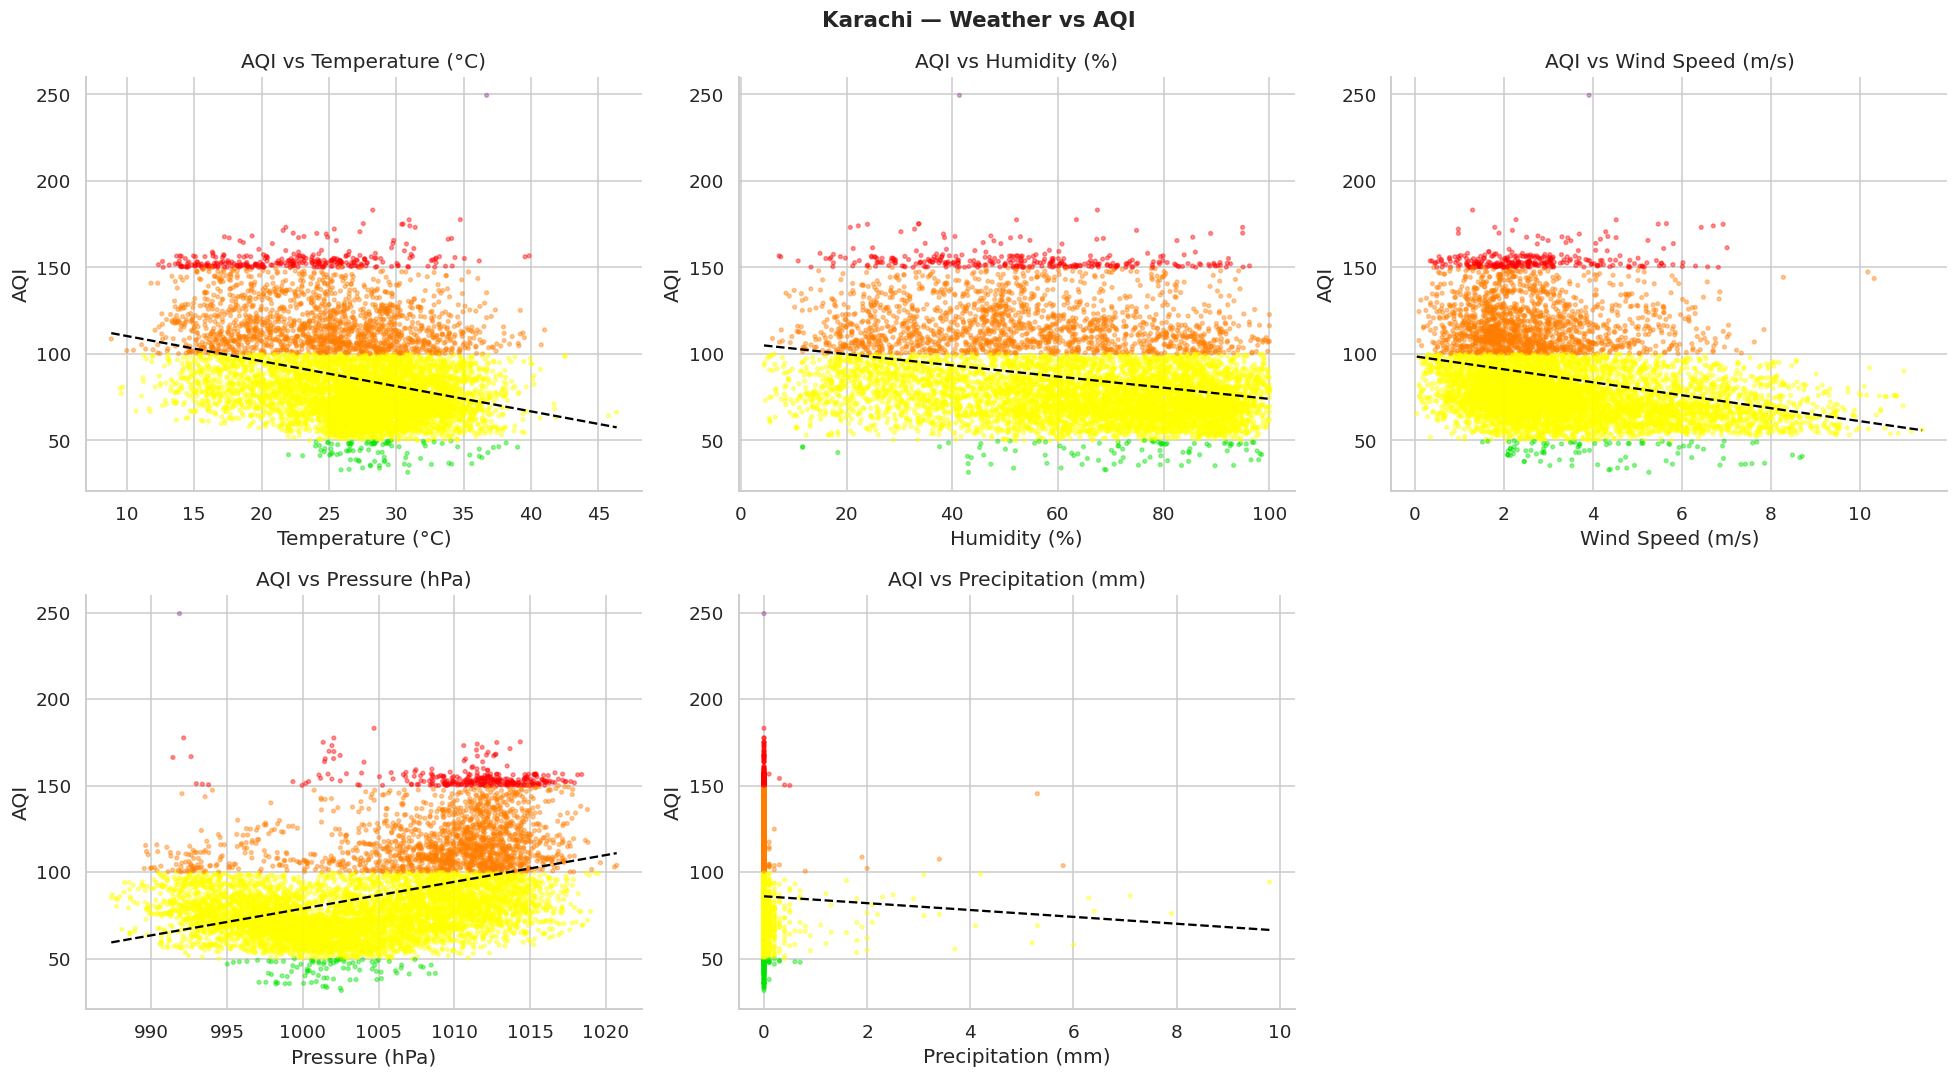

In [10]:
weather_vars = [("temperature","Temperature (°C)"),("humidity","Humidity (%)"),
                ("wind_speed","Wind Speed (m/s)"),("pressure","Pressure (hPa)"),
                ("precipitation","Precipitation (mm)")]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Karachi — Weather vs AQI", fontsize=14, fontweight="bold")
axes = axes.flatten()

sample = df.sample(min(8000, len(df)), random_state=42)
colors = sample["aqi_category"].map(lambda c: CAT_PALETTE[int(c)] if not pd.isna(c) else "#aaa")

for i, (col, label) in enumerate(weather_vars):
    if col in df.columns:
        axes[i].scatter(sample[col], sample["aqi"], c=colors, s=6, alpha=0.4)
        axes[i].set_xlabel(label); axes[i].set_ylabel("AQI"); axes[i].set_title(f"AQI vs {label}")
        valid = sample[[col,"aqi"]].dropna()
        if len(valid) > 10:
            z = np.polyfit(valid[col], valid["aqi"], 1)
            xs = np.linspace(valid[col].min(), valid[col].max(), 100)
            axes[i].plot(xs, np.poly1d(z)(xs), color="black", lw=1.5, ls="--")

axes[5].axis("off")
plt.tight_layout()
plt.savefig(PLOT_DIR / "06_weather_aqi_scatter.png", bbox_inches="tight")
plt.show()

## 7. Pollutant Distributions & Correlation with AQI

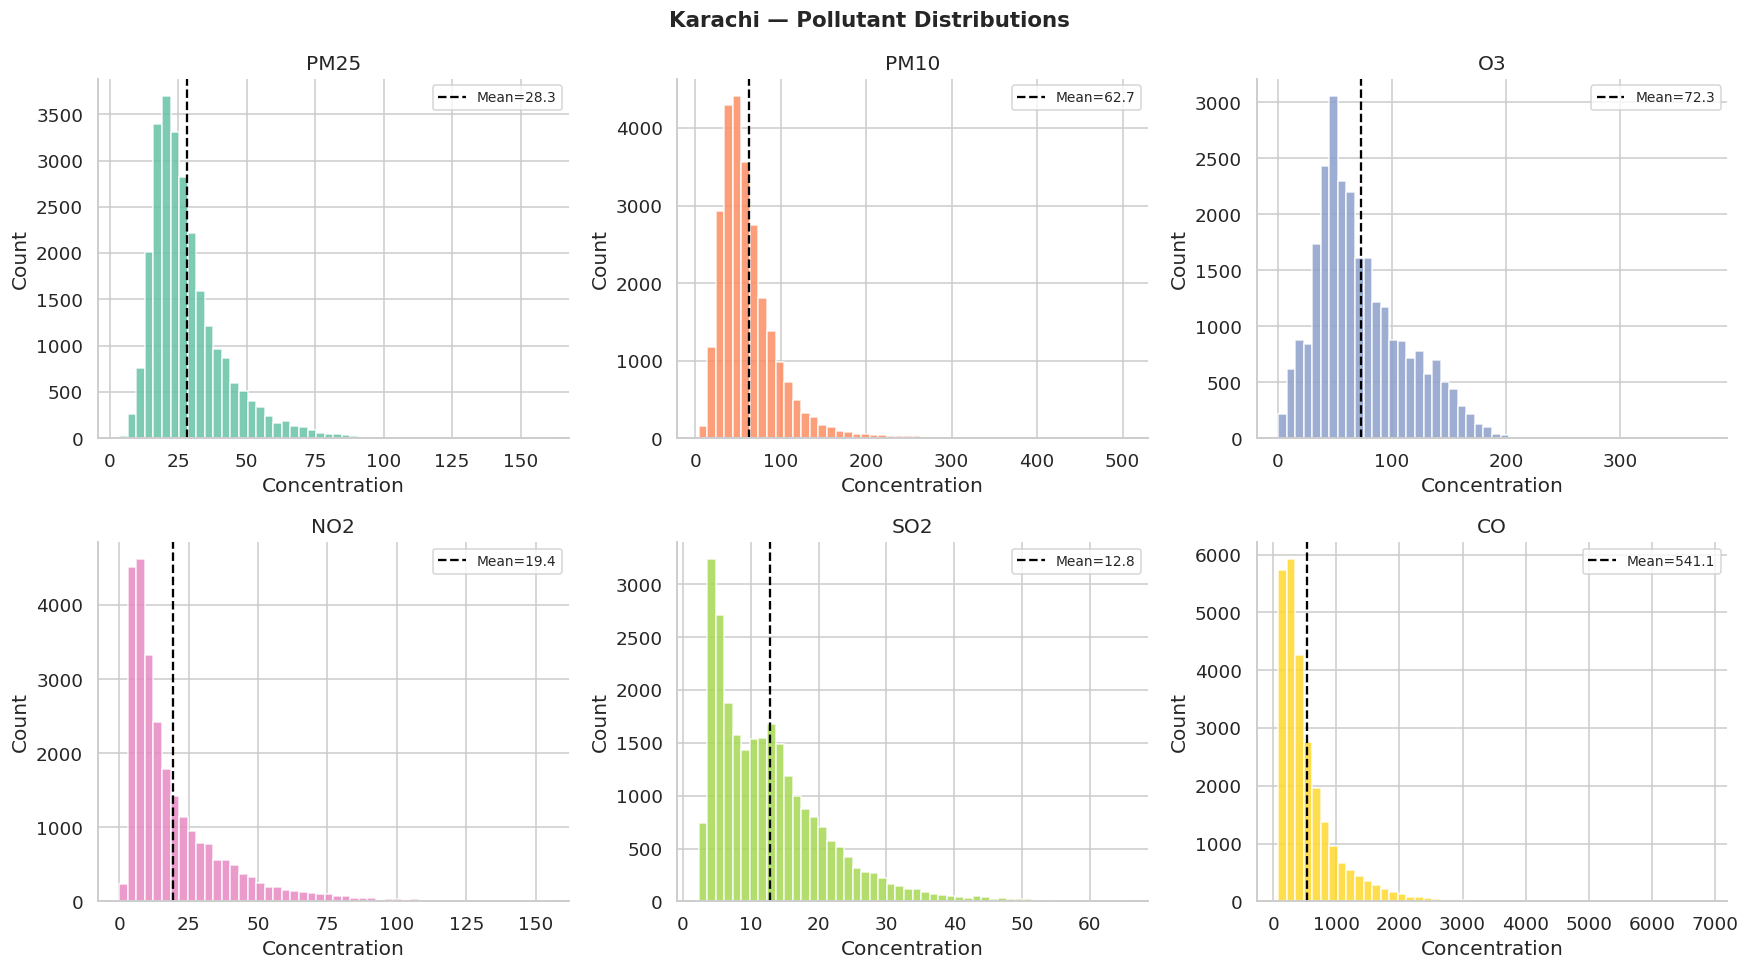

In [11]:
pollutants = [p for p in ["pm25","pm10","o3","no2","so2","co"] if p in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Karachi — Pollutant Distributions", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, pol in enumerate(pollutants):
    axes[i].hist(df[pol].dropna(), bins=50, color=sns.color_palette("Set2")[i],
                 edgecolor="white", alpha=0.85)
    axes[i].set_title(pol.upper()); axes[i].set_xlabel("Concentration"); axes[i].set_ylabel("Count")
    axes[i].axvline(df[pol].mean(), color="black", ls="--", lw=1.5, label=f"Mean={df[pol].mean():.1f}")
    axes[i].legend(fontsize=9)

for j in range(len(pollutants), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(PLOT_DIR / "07_pollutant_distributions.png", bbox_inches="tight")
plt.show()

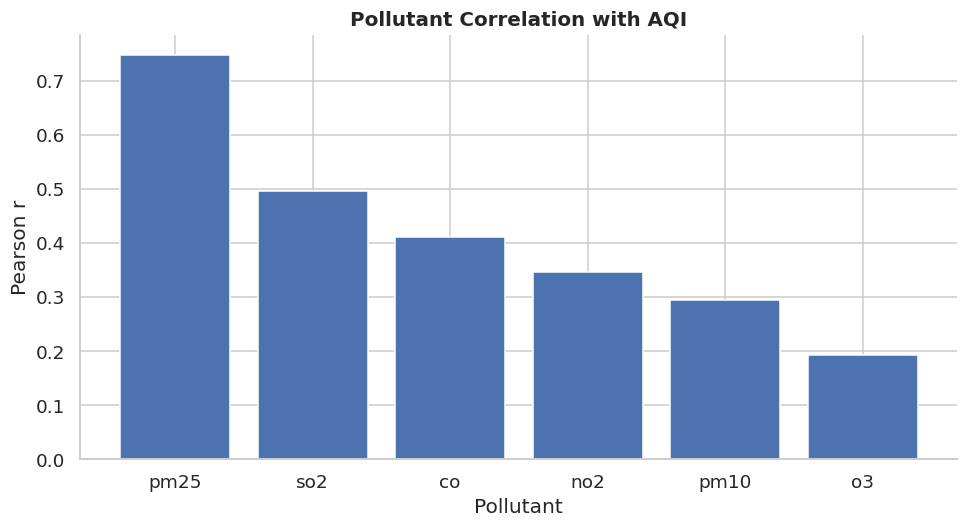

In [12]:
# Pollutant correlation with AQI
corrs = {p: df[p].corr(df["aqi"]) for p in pollutants}
sorted_corrs = dict(sorted(corrs.items(), key=lambda x: abs(x[1]), reverse=True))

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ["#4C72B0" if v >= 0 else "#C44E52" for v in sorted_corrs.values()]
ax.bar(list(sorted_corrs.keys()), list(sorted_corrs.values()), color=colors_bar)
ax.set_title("Pollutant Correlation with AQI", fontsize=13, fontweight="bold")
ax.set_xlabel("Pollutant"); ax.set_ylabel("Pearson r"); ax.axhline(0, color="black", lw=0.8)
plt.tight_layout()
plt.savefig(PLOT_DIR / "08_pollutant_aqi_correlation.png", bbox_inches="tight")
plt.show()

## 8. Autocorrelation at Key Lags

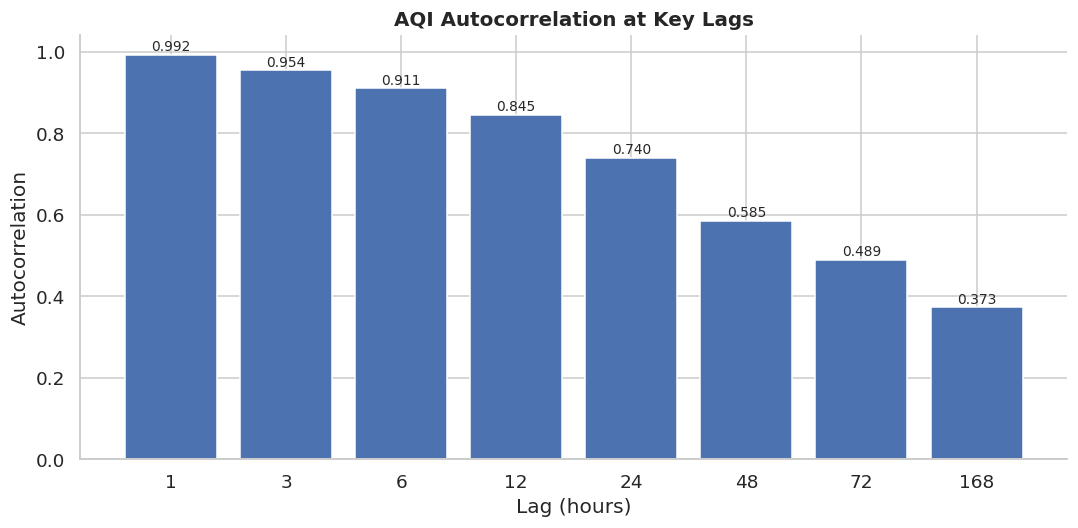

Key insight: lag1 and lag24 have highest autocorrelation — justifies using these as features


In [13]:
aqi = df["aqi"].dropna()
lags  = [1, 3, 6, 12, 24, 48, 72, 168]
corrs = [aqi.autocorr(lag=l) for l in lags]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([str(l) for l in lags], corrs, color="#4C72B0")
ax.set_xlabel("Lag (hours)"); ax.set_ylabel("Autocorrelation")
ax.set_title("AQI Autocorrelation at Key Lags", fontsize=13, fontweight="bold")
ax.axhline(0, color="black", lw=0.8)
for i, (l, c) in enumerate(zip(lags, corrs)):
    ax.text(i, c + 0.01*np.sign(c), f"{c:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(PLOT_DIR / "09_autocorrelation.png", bbox_inches="tight")
plt.show()

print("Key insight: lag1 and lag24 have highest autocorrelation — justifies using these as features")

## 9. Rolling Statistics (Last 90 Days)

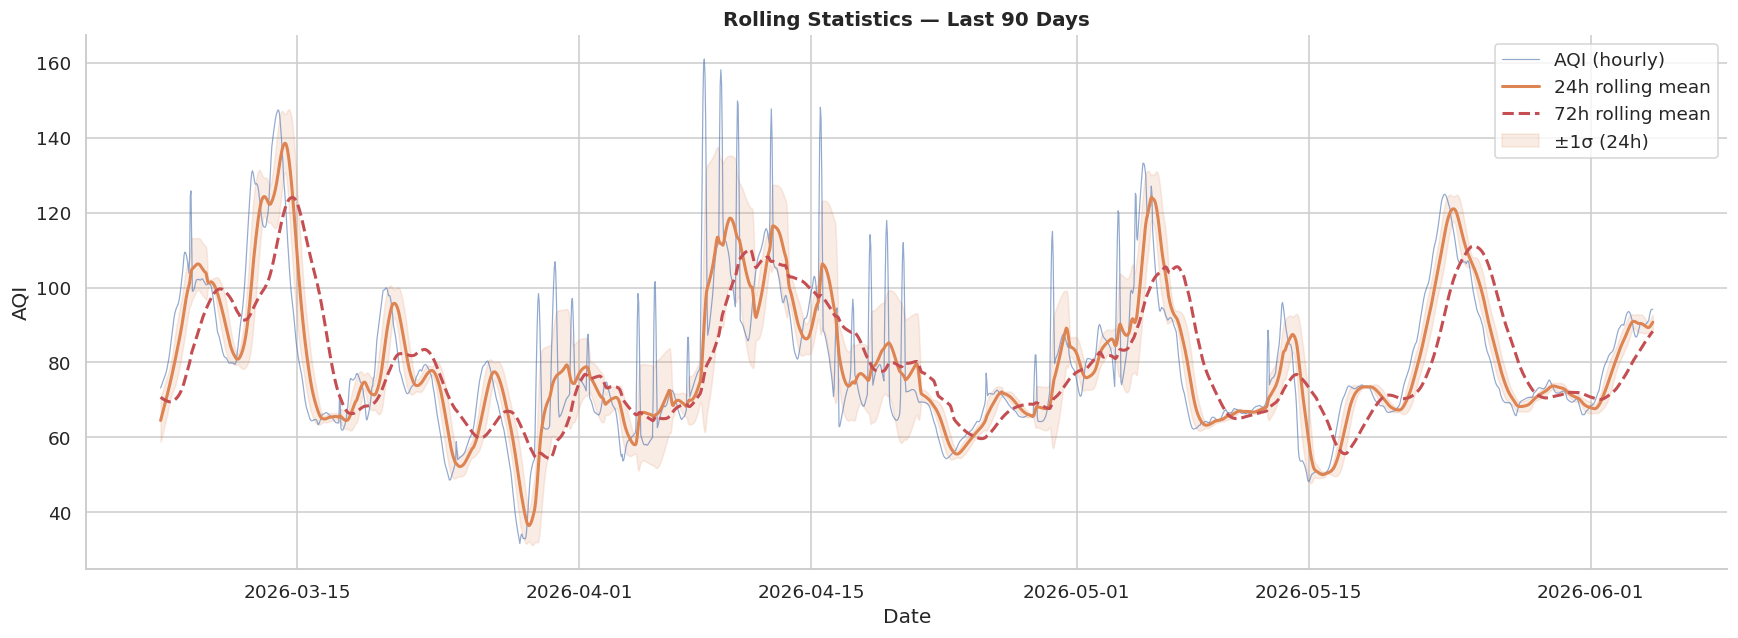

In [14]:
start  = df["timestamp"].max() - pd.Timedelta(days=90)
window = df[df["timestamp"] >= start].copy()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(window["timestamp"], window["aqi"], color="#4C72B0", lw=0.8, alpha=0.6, label="AQI (hourly)")
ax.plot(window["timestamp"], window["aqi_rolling_mean_24h"], color="#DD8452", lw=2, label="24h rolling mean")
ax.plot(window["timestamp"], window["aqi_rolling_mean_72h"], color="#C44E52", lw=2, ls="--", label="72h rolling mean")
ax.fill_between(window["timestamp"],
                window["aqi_rolling_mean_24h"] - window["aqi_rolling_std_24h"],
                window["aqi_rolling_mean_24h"] + window["aqi_rolling_std_24h"],
                alpha=0.15, color="#DD8452", label="±1σ (24h)")
ax.set_xlabel("Date"); ax.set_ylabel("AQI")
ax.set_title("Rolling Statistics — Last 90 Days", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "10_rolling_stats.png", bbox_inches="tight")
plt.show()

## 10. Correlation Heatmap

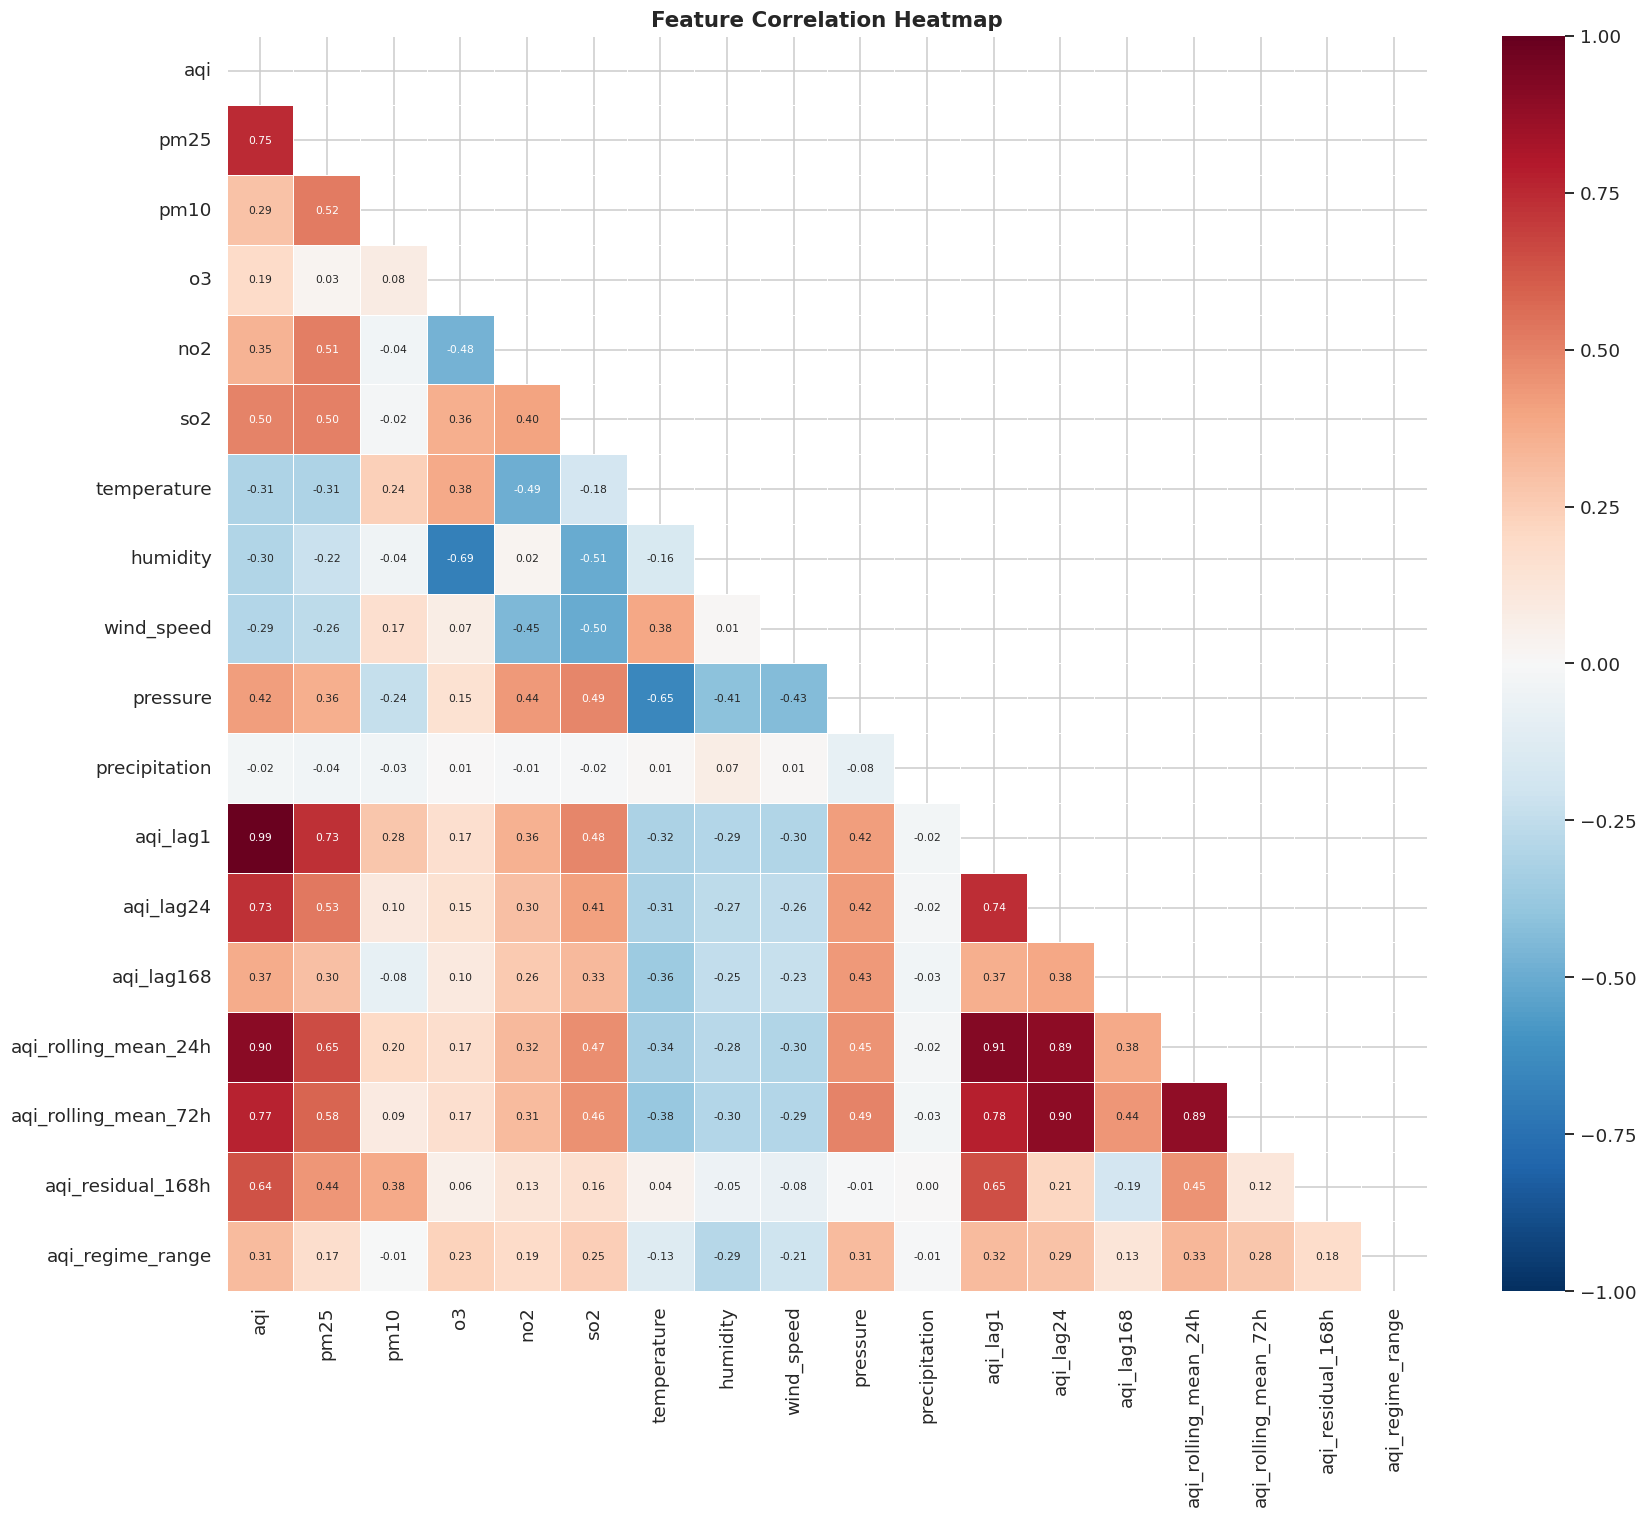

In [15]:
key_cols = ["aqi","pm25","pm10","o3","no2","so2",
            "temperature","humidity","wind_speed","pressure","precipitation",
            "aqi_lag1","aqi_lag24","aqi_lag168",
            "aqi_rolling_mean_24h","aqi_rolling_mean_72h",
            "aqi_residual_168h","aqi_regime_range"]
available = [c for c in key_cols if c in df.columns]

corr_matrix = df[available].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_matrix, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7}, linewidths=0.4, ax=ax)
ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "11_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 11. Outlier Analysis

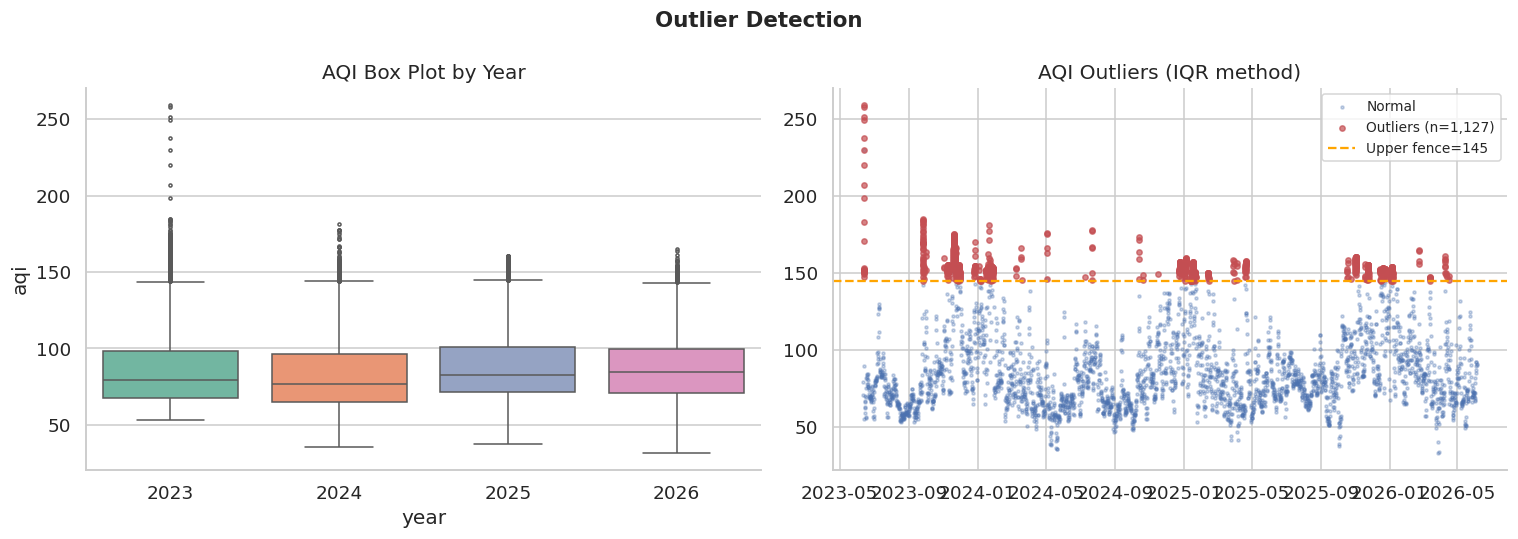

Outliers: 1,127  (4.3%)


In [16]:
q1, q3 = df["aqi"].quantile(0.25), df["aqi"].quantile(0.75)
iqr     = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = df[(df["aqi"] < lower) | (df["aqi"] > upper)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Outlier Detection", fontsize=14, fontweight="bold")

df2 = df.copy(); df2["year"] = df2["timestamp"].dt.year
sns.boxplot(data=df2, x="year", y="aqi", palette="Set2", ax=axes[0], fliersize=2)
axes[0].set_title("AQI Box Plot by Year")

step = max(1, len(df)//3000)
axes[1].scatter(df["timestamp"][::step], df["aqi"][::step], s=4, alpha=0.3, color="#4C72B0", label="Normal")
if len(outliers) > 0:
    axes[1].scatter(outliers["timestamp"], outliers["aqi"], s=12, alpha=0.7, color="#C44E52",
                    label=f"Outliers (n={len(outliers):,})")
axes[1].axhline(upper, color="orange", ls="--", lw=1.5, label=f"Upper fence={upper:.0f}")
axes[1].set_title("AQI Outliers (IQR method)"); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR / "12_outliers.png", bbox_inches="tight")
plt.show()
print(f"Outliers: {len(outliers):,}  ({100*len(outliers)/len(df):.1f}%)")

## 12. Target Variable Analysis (Day1 / Day2 / Day3)

In [17]:
day_targets = [c for c in ["target_day1","target_day2","target_day3"] if c in df.columns]

if day_targets:
    fig, axes = plt.subplots(1, len(day_targets), figsize=(6*len(day_targets), 5))
    fig.suptitle("Target AQI Distributions", fontsize=14, fontweight="bold")
    if len(day_targets) == 1: axes = [axes]

    for i, col in enumerate(day_targets):
        axes[i].hist(df[col].dropna(), bins=60, color=["#4C72B0","#DD8452","#55A868"][i],
                     edgecolor="white", alpha=0.85)
        axes[i].axvline(df[col].mean(), color="red", ls="--", lw=1.5, label=f"Mean={df[col].mean():.1f}")
        axes[i].set_title(col.replace("_"," ").title()); axes[i].legend()

    plt.tight_layout()
    plt.savefig(PLOT_DIR / "13_target_distributions.png", bbox_inches="tight")
    plt.show()
else:
    print("target_day1/2/3 not in CSV — these are built during training pipeline")

target_day1/2/3 not in CSV — these are built during training pipeline


## 13. v6 Residual / Regime Features

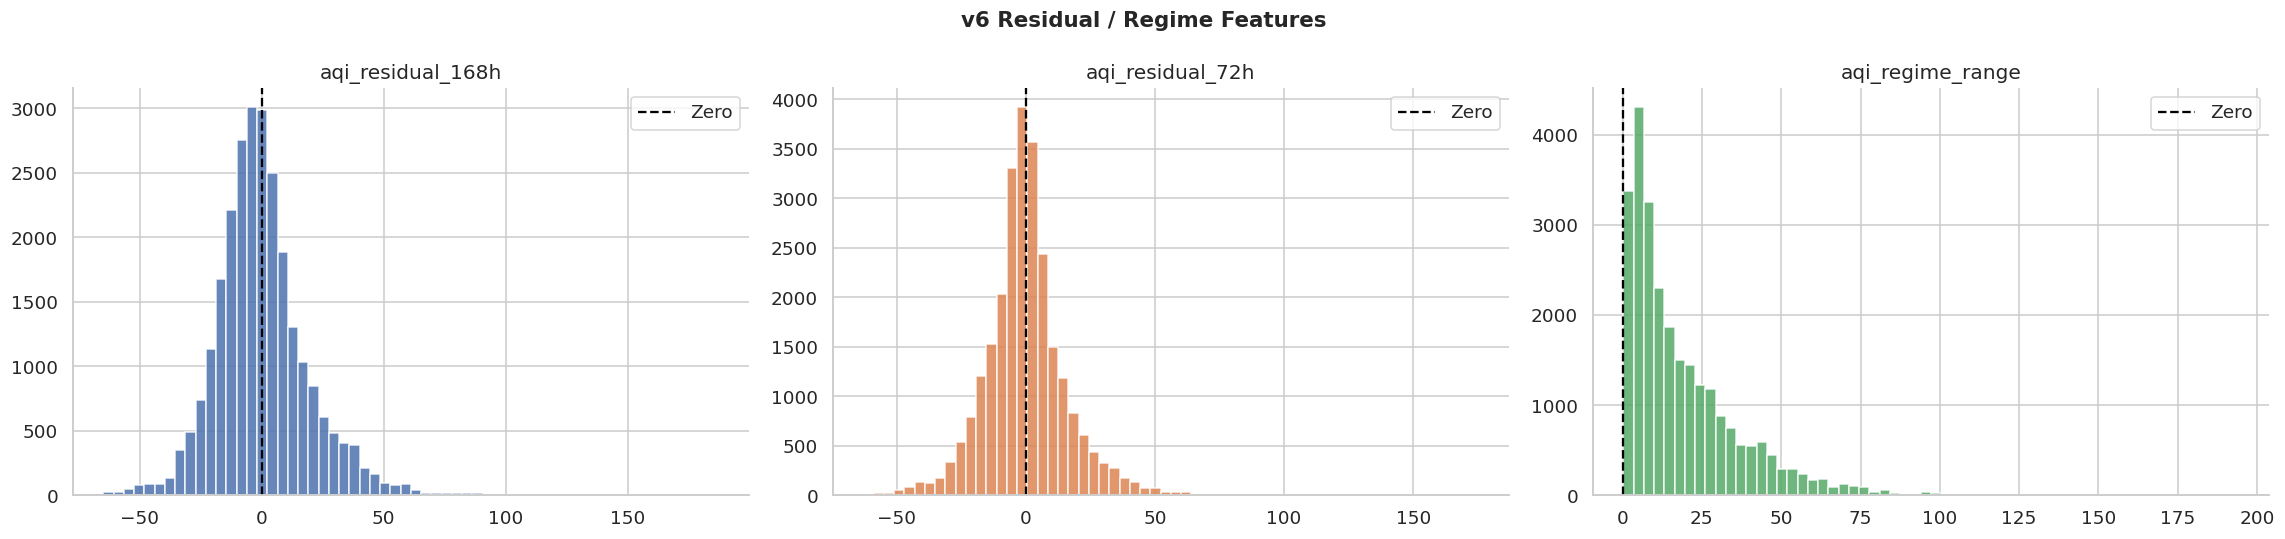

aqi_residual_168h mean: 0.06
aqi_residual_72h  mean: 0.04
aqi_regime_range  mean: 19.09


In [18]:
v6_cols = [c for c in ["aqi_residual_168h","aqi_residual_72h","aqi_regime_range"] if c in df.columns]

if v6_cols:
    fig, axes = plt.subplots(1, len(v6_cols), figsize=(7*len(v6_cols), 5))
    fig.suptitle("v6 Residual / Regime Features", fontsize=14, fontweight="bold")
    if len(v6_cols) == 1: axes = [axes]

    for i, col in enumerate(v6_cols):
        axes[i].hist(df[col].dropna(), bins=60, color=["#4C72B0","#DD8452","#55A868"][i],
                     edgecolor="white", alpha=0.85)
        axes[i].axvline(0, color="black", ls="--", lw=1.5, label="Zero")
        axes[i].set_title(col); axes[i].legend()

    plt.tight_layout()
    plt.savefig(PLOT_DIR / "14_residual_regime.png", bbox_inches="tight")
    plt.show()
    print(f"aqi_residual_168h mean: {df['aqi_residual_168h'].mean():.2f}")
    print(f"aqi_residual_72h  mean: {df['aqi_residual_72h'].mean():.2f}")
    print(f"aqi_regime_range  mean: {df['aqi_regime_range'].mean():.2f}")

## 14. Summary Statistics

In [19]:
print("="*55)
print("SUMMARY STATISTICS — Karachi AQI (3-Year Hourly)")
print("="*55)
stats = {
    "Total records":           f"{len(df):,}",
    "Date range":              f"{df['timestamp'].min().date()} → {df['timestamp'].max().date()}",
    "AQI mean ± std":          f"{df['aqi'].mean():.1f} ± {df['aqi'].std():.1f}",
    "AQI min / max":           f"{df['aqi'].min():.0f} / {df['aqi'].max():.0f}",
    "% Good (0-50)":           f"{100*(df['aqi'] <= 50).mean():.1f}%",
    "% Moderate (51-100)":     f"{100*((df['aqi']>50)&(df['aqi']<=100)).mean():.1f}%",
    "% Unhealthy (101-200)":   f"{100*((df['aqi']>100)&(df['aqi']<=200)).mean():.1f}%",
    "% Very Unhealthy (201+)": f"{100*(df['aqi']>200).mean():.1f}%",
    "PM2.5 mean":              f"{df['pm25'].mean():.1f} µg/m³",
    "PM10 mean":               f"{df['pm10'].mean():.1f} µg/m³",
    "Lag1 autocorr":           f"{df['aqi'].autocorr(1):.4f}",
    "Lag24 autocorr":          f"{df['aqi'].autocorr(24):.4f}",
    "Lag168 autocorr":         f"{df['aqi'].autocorr(168):.4f}",
}
for k, v in stats.items():
    print(f"  {k:<28} {v}")
print(f"\n✅ All plots saved to: eda_plots/")

SUMMARY STATISTICS — Karachi AQI (3-Year Hourly)
  Total records                26,136
  Date range                   2023-06-11 → 2026-06-04
  AQI mean ± std               86.3 ± 25.2
  AQI min / max                32 / 259
  % Good (0-50)                1.2%
  % Moderate (51-100)          74.9%
  % Unhealthy (101-200)        23.8%
  % Very Unhealthy (201+)      0.0%
  PM2.5 mean                   28.3 µg/m³
  PM10 mean                    62.7 µg/m³
  Lag1 autocorr                0.9920
  Lag24 autocorr               0.7398
  Lag168 autocorr              0.3729

✅ All plots saved to: eda_plots/
